# Monte Carlo Methods

            ## 1. Learning objectives

            - Calculate returns-to-go
- Implement first-visit value estimation
- Explain why complete episodes are required

            ## 2. Prerequisites

            Python loops, NumPy arrays, probability, expected value, and basic supervised-learning vocabulary.

In [1]:
from pathlib import Path
import sys

project_root = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.notebook_utils import RANDOM_SEED, set_seed
from src.plotting import COURSE_COLORS, set_course_style

set_seed(RANDOM_SEED)
set_course_style()
rng = np.random.default_rng(RANDOM_SEED)
print(f"Python lesson ready; reproducible seed = {RANDOM_SEED}")


def plot_rl_metrics(rewards, exploration_rates, episode_lengths, title):
    rewards = np.asarray(rewards, dtype=float)
    window = min(20, len(rewards))
    moving = np.convolve(rewards, np.ones(window)/window, mode="valid")
    episodes = np.arange(1, len(rewards)+1)
    figure, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
    axes[0].plot(episodes, rewards, alpha=.35, color=COURSE_COLORS["blue"], label="Episode reward")
    axes[0].plot(episodes[window-1:], moving, color=COURSE_COLORS["orange"], label=f"{window}-episode average")
    axes[0].set(title=title, ylabel="Reward"); axes[0].legend()
    axes[1].plot(episodes, exploration_rates, color=COURSE_COLORS["olive"])
    axes[1].set(ylabel="Exploration rate")
    axes[2].plot(episodes, episode_lengths, color=COURSE_COLORS["pink"])
    axes[2].set(xlabel="Episode", ylabel="Episode length")
    figure.tight_layout()
    plt.show()

Python lesson ready; reproducible seed = 42


## 3. Problem definition

            Estimate values directly from sampled complete returns without a transition model.

            ## 4. Real-world use cases

            - Adaptive control
- Resource allocation
- Sequential recommendation experiments

            ## 5. Core intuition in simple language

            Finish an episode, look backward at what each visited state eventually earned, and average those outcomes.

## 6. Mathematical foundation

            $$V(s)\leftarrow V(s)+\frac{1}{N(s)}[G-V(s)].$$

            **Every symbol:**

            - $V(s)$ is estimated state value.
- $N(s)$ is visit count.
- $G$ is sampled return from the visit.

            **Why the equation is needed:** It incrementally averages unbiased sampled returns for a fixed policy.

            **Small numerical example:** Old value .4 after four returns and new return 1 gives .4+(1-.4)/5=.52.

            **Connection to Python:** values[state] += (return-value)/count is the incremental mean update.

## 7. Visual explanation

            The executable figure below is chosen to reveal the structure this method learns. Read positions and lengths first; color is a supporting cue rather than the only encoding.

            ## 8. Algorithm steps

            1. Reset the environment
2. Observe state
3. Choose an action from the policy
4. Receive next state and reward
5. Update values or policy
6. Repeat until termination and across episodes

## 9. Implementation from scratch

A tiny custom environment keeps states, actions, rewards, and transitions visible.

The simplified implementation exposes the central mechanism. It favors readability over production-scale numerical safeguards.

In [2]:
def returns_from_rewards(rewards,gamma):
    returns=np.zeros(len(rewards)); running=0.0
    for index in range(len(rewards)-1,-1,-1):
        running=rewards[index]+gamma*running
        returns[index]=running
    return returns

print("Returns-to-go:",returns_from_rewards([0,0,1],.9).round(3))

Returns-to-go: [0.81 0.9  1.  ]


## 10. Implementation using a standard library

NumPy handles tabular methods; PyTorch is introduced only for value or policy function approximation.

## 11. Dataset loading and exploration

Reinforcement learning generates experience through environment interaction rather than loading labeled rows.

## 12. Data preprocessing

Discrete states are indexed directly; neural agents convert states to normalized float tensors.

## 13. Model training

The next cell trains both the transparent and library-backed versions where the topic has a trainable model.

## 14. Predictions

Predictions, transformed representations, actions, or value estimates are kept in named arrays so their shapes can be inspected.

## 15. Evaluation

Evaluation uses a metric appropriate to the learning setting and always retains a simple baseline or reasonableness check.

## 16. Visualization of results

Every chart has a descriptive title and labeled axes. The interpretation immediately below describes what the marks mean.

Estimated nonterminal values: [0.142 0.298 0.482 0.668 0.837]
Analytic values: [0.16666667 0.33333333 0.5        0.66666667 0.83333333]


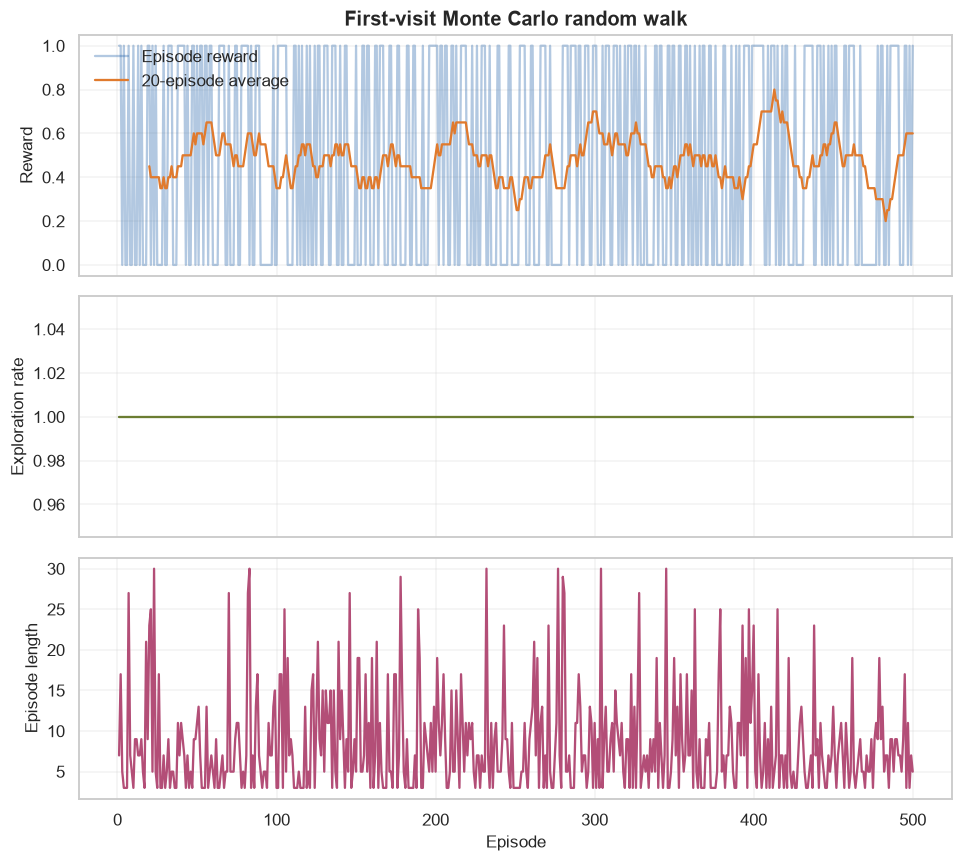

In [3]:
state_count=7
values=np.zeros(state_count)
counts=np.zeros(state_count)
rewards_history=[]; exploration_rates=[]; lengths=[]
for episode in range(500):
    state=3; visited=[]; rewards=[]
    for step in range(30):
        visited.append(state)
        state+=-1 if rng.random()<.5 else 1
        reward=1.0 if state==state_count-1 else 0.0
        rewards.append(reward)
        if state in [0,state_count-1]: break
    returns=returns_from_rewards(rewards,1.0)
    seen=set()
    for visited_state,ret in zip(visited,returns):
        if visited_state not in seen:
            counts[visited_state]+=1
            values[visited_state]+=(ret-values[visited_state])/counts[visited_state]
            seen.add(visited_state)
    rewards_history.append(sum(rewards)); exploration_rates.append(1.0); lengths.append(step+1)
print("Estimated nonterminal values:",values[1:-1].round(3))
print("Analytic values:",np.arange(1,state_count-1)/(state_count-1))
plot_rl_metrics(rewards_history,exploration_rates,lengths,"First-visit Monte Carlo random walk")

**How to interpret the result:** Values rise toward the rewarding right terminal. Individual episode rewards stay binary and noisy, so averaging is essential.

**Scratch-to-library comparison:**

- **Performance:** the educational implementation favors visible steps; the library implementation uses optimized, vectorized, and often compiled routines.
- **Numerical stability:** production libraries add convergence checks, guarded arithmetic, and tested handling of edge cases that the compact scratch version intentionally omits.
- **Flexibility:** scratch code is easy to inspect and change for one lesson, while the library version supports reusable estimator interfaces, pipelines, and broader input cases.
- **Complexity:** the scratch implementation makes the central mechanism explicit; the library hides additional validation and engineering complexity behind a small public API.

Compare the measured outputs above rather than expecting exact equality: initialization, stopping rules, regularization, and implementation details can differ.

## 17. Hyperparameter experiments

More episodes reduce sampling noise; the running success rate makes convergence visible.

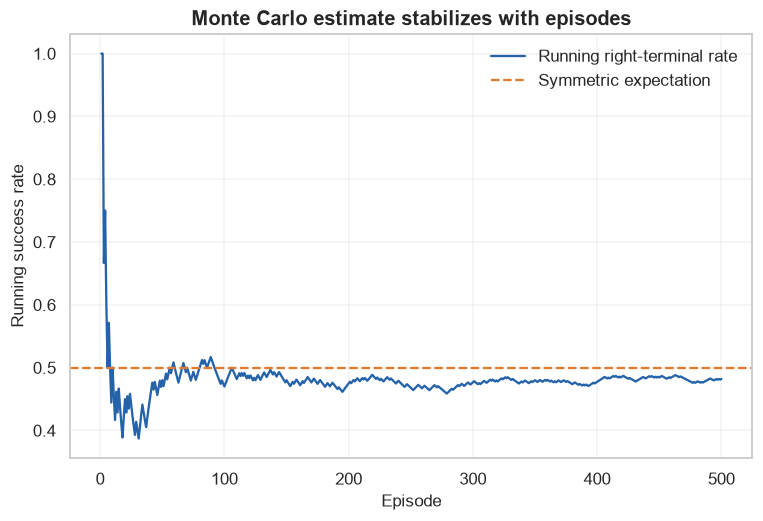

In [4]:
episodes=np.arange(1,len(rewards_history)+1)
running_success=np.cumsum(rewards_history)/episodes
figure,axis=plt.subplots(); axis.plot(episodes,running_success,color=COURSE_COLORS["blue"],label="Running right-terminal rate")
axis.axhline(.5,color=COURSE_COLORS["orange"],linestyle="--",label="Symmetric expectation")
axis.set(title="Monte Carlo estimate stabilizes with episodes",xlabel="Episode",ylabel="Running success rate"); axis.legend(); plt.show()

## 18. Common mistakes

            - Treating reward as a supervised label
- Evaluating while exploration is still active
- Comparing agents with different random seeds or episode limits
- Ignoring truncation versus true termination

            ## 19. Advantages and disadvantages

            **Advantages**

            - Directly optimizes sequential behavior
- Can learn from interaction without action labels

            **Disadvantages**

            - Experience can be expensive or unsafe
- Results are noisy and sensitive to reward design

            ## 20. When to use and when not to use the algorithm

            **Use it when:** actions influence future states and the objective is naturally expressed through cumulative reward.

            **Do not use it when:** a static labeled prediction problem is sufficient or unsafe exploration cannot be controlled.

## 21. Exercises

1. **Conceptual:** Why is RL not supervised learning?
2. **Mathematical/hand calculation:** Calculate return for rewards [2,0,4] with gamma=.5.
3. **Coding/experimentation:** Change one hyperparameter and compare learning across at least three seeds.

<details>
<summary><strong>22. Exercise solutions</strong></summary>

1. The agent is not given correct actions; it receives consequences and must handle delayed credit.
2. 2+.5(0)+.25(4)=3.
3. Keep all other settings fixed, plot each seed plus aggregate mean, and avoid selecting only the best run.

</details>

## 23. Summary and key takeaways

            - The policy maps states to action choices
- Return assigns credit across time
- Exploration gathers information while exploitation uses current knowledge
- Learning curves require repeated, controlled evaluation

            ## 24. Further reading

            - [Gymnasium documentation](https://gymnasium.farama.org/)
- [Sutton and Barto: Reinforcement Learning](http://incompleteideas.net/book/the-book-2nd.html)